# Unified PICO Pipeline Evaluation

This notebook evaluates every pipeline variant that outputs the shared prediction-table format:

`method, doc_id, text, Pop_gold, Pop_pred, Int_gold, Int_pred, Out_gold, Out_pred`

It covers three required evaluation views:

1. Field-level accuracy / precision / recall / F1.
2. Coverage vs precision, including hallucination and over-extraction indicators.
3. Downstream usability: whether P/I/O queries can be answered and whether complete PIO records are usable.

## Evaluation Design

The prediction formats are not identical in granularity: LLM variants often predict short spans, while ML and clustering variants often predict whole sentences. For that reason this notebook uses several complementary metrics instead of relying on exact match only.

- **Exact match**: strict normalized string match. Useful but harsh.
- **Token precision**: how much of the predicted content overlaps with gold.
- **Token recall**: how much of the gold content is recovered.
- **Token F1**: balanced span overlap score.
- **Relaxed match**: token F1 >= threshold, default `0.50`.
- **Coverage**: how often the method returns a non-null answer.
- **Lexical unsupported rate**: among non-null predictions, proportion containing tokens not found in the original abstract. This is a lexical groundedness measure, not a full semantic hallucination detector.
- **Downstream usability**: whether Pop/Int/Out queries and complete PIO records can be answered.

Exact match is reported as a strict reference metric, but token-level overlap F1 is the main metric because different pipelines produce outputs at different granularities: clustering and ML variants often output whole sentences, while LLM variants often output shorter phrases or lightly normalized spans.

In [23]:
from pathlib import Path
import ast
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

PROJECT_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / "task2-ml").exists() and (p / "task2-llm").exists()),
    Path.cwd().resolve(),
)

OUTPUT_DIR = PROJECT_ROOT / "evaluation_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

FIELDS = ["Pop", "Int", "Out"]
RELAXED_F1_THRESHOLD = 0.50

print("Project root:", PROJECT_ROOT)
print("Evaluation outputs:", OUTPUT_DIR)

Project root: Y:\222
Evaluation outputs: Y:\222\evaluation_outputs


In [24]:
prediction_files = [
    PROJECT_ROOT / "task1-cluster" / "cluster_kmeans_predictions.csv",
    PROJECT_ROOT / "task2-ml" / "ml_end_to_end_predictions.csv",
    PROJECT_ROOT / "task2-ml" / "ml_decomposed_predictions.csv",
]

# Pick up any LLM outputs once they are regenerated.
prediction_files.extend(sorted((PROJECT_ROOT / "task2-llm").glob("*_predictions.csv")))

prediction_files = [p for p in prediction_files if p.exists()]
prediction_files

[WindowsPath('Y:/222/task1-cluster/cluster_kmeans_predictions.csv'),
 WindowsPath('Y:/222/task2-ml/ml_end_to_end_predictions.csv'),
 WindowsPath('Y:/222/task2-ml/ml_decomposed_predictions.csv'),
 WindowsPath('Y:/222/task2-llm/llm_dynamic_1_shot_predictions.csv'),
 WindowsPath('Y:/222/task2-llm/llm_dynamic_2_shot_predictions.csv'),
 WindowsPath('Y:/222/task2-llm/llm_dynamic_3_shot_predictions.csv'),
 WindowsPath('Y:/222/task2-llm/llm_dynamic_4_shot_predictions.csv'),
 WindowsPath('Y:/222/task2-llm/llm_dynamic_5_shot_predictions.csv'),
 WindowsPath('Y:/222/task2-llm/llm_zero_shot_predictions.csv')]

In [25]:
REQUIRED_COLUMNS = [
    "method", "doc_id", "text",
    "Pop_gold", "Pop_pred",
    "Int_gold", "Int_pred",
    "Out_gold", "Out_pred",
]

frames = []
for path in prediction_files:
    df = pd.read_csv(path, keep_default_na=False)
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing columns: {missing}")
    df = df[REQUIRED_COLUMNS].copy()
    df["source_file"] = path.relative_to(PROJECT_ROOT).as_posix()
    frames.append(df)

predictions = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=REQUIRED_COLUMNS + ["source_file"])

summary = (
    predictions.groupby(["method", "source_file"], dropna=False)
    .agg(rows=("doc_id", "size"), docs=("doc_id", "nunique"), duplicate_doc_rows=("doc_id", lambda s: int(s.duplicated().sum())))
    .reset_index()
)
summary

,method,source_file,rows,docs,duplicate_doc_rows
0,cluster_kmeans,task1-cluster/cluster_kmeans_predictions.csv,184,184,0
1,llm_dynamic_1_shot,task2-llm/llm_dynamic_1_shot_predictions.csv,184,184,0
2,llm_dynamic_2_shot,task2-llm/llm_dynamic_2_shot_predictions.csv,184,184,0
3,llm_dynamic_3_shot,task2-llm/llm_dynamic_3_shot_predictions.csv,184,184,0
4,llm_dynamic_4_shot,task2-llm/llm_dynamic_4_shot_predictions.csv,184,184,0
5,llm_dynamic_5_shot,task2-llm/llm_dynamic_5_shot_predictions.csv,184,184,0
6,llm_zero_shot,task2-llm/llm_zero_shot_predictions.csv,184,184,0
7,ml_decomposed,task2-ml/ml_decomposed_predictions.csv,184,184,0
8,ml_end_to_end,task2-ml/ml_end_to_end_predictions.csv,184,184,0


## Normalization Helpers

These helpers make evaluation robust to LLM outputs such as Python-style lists (`['aspirin', 'placebo']`), JSON-ish values, empty strings, `None`, and `null`.

In [26]:
NULL_STRINGS = {"", "null", "none", "nan", "[]", "{}"}
TOKEN_RE = re.compile(r"[a-z0-9]+(?:[-'][a-z0-9]+)?", re.IGNORECASE)


def normalize_prediction_value(value):
    if value is None:
        return "null"
    text = str(value).strip()
    if text.lower() in NULL_STRINGS:
        return "null"

    # Convert Python-list-like LLM outputs into the same semicolon format.
    if (text.startswith("[") and text.endswith("]")) or (text.startswith("{") and text.endswith("}")):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, dict):
                parsed = list(parsed.values())
            if isinstance(parsed, (list, tuple, set)):
                items = [normalize_prediction_value(x) for x in parsed]
                items = [x for x in items if x.lower() != "null"]
                return " ; ".join(items) if items else "null"
        except Exception:
            pass

    text = re.sub(r"\s+", " ", text)
    return text.strip() if text.strip().lower() not in NULL_STRINGS else "null"


def is_present(value):
    return normalize_prediction_value(value).lower() != "null"


def tokens(value):
    value = normalize_prediction_value(value)
    if value.lower() == "null":
        return []
    return TOKEN_RE.findall(value.lower())


def token_overlap_counts(gold, pred):
    gold_tokens = tokens(gold)
    pred_tokens = tokens(pred)
    gold_counts = pd.Series(gold_tokens).value_counts().to_dict()
    pred_counts = pd.Series(pred_tokens).value_counts().to_dict()
    overlap = sum(min(gold_counts.get(tok, 0), pred_counts.get(tok, 0)) for tok in pred_counts)
    return overlap, len(gold_tokens), len(pred_tokens)


def token_scores(gold, pred):
    overlap, gold_n, pred_n = token_overlap_counts(gold, pred)
    if gold_n == 0 and pred_n == 0:
        return 1.0, 1.0, 1.0
    if gold_n == 0 or pred_n == 0:
        return 0.0, 0.0, 0.0
    precision = overlap / pred_n if pred_n else 0.0
    recall = overlap / gold_n if gold_n else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1


def normalized_exact(gold, pred):
    return " ".join(tokens(gold)) == " ".join(tokens(pred))


def hallucination_fraction(pred, abstract_text):
    pred_tokens = tokens(pred)
    if not pred_tokens:
        return np.nan
    text_token_set = set(tokens(abstract_text))
    missing = [tok for tok in pred_tokens if tok not in text_token_set]
    return len(missing) / len(pred_tokens)


def split_prediction_parts(value):
    value = normalize_prediction_value(value)
    if value.lower() == "null":
        return []
    return [part.strip() for part in value.split(" ; ") if part.strip()]


def verbatim_match_rate(pred, abstract_text):
    parts = split_prediction_parts(pred)
    if not parts:
        return np.nan
    text = str(abstract_text).lower()
    return sum(part.lower() in text for part in parts) / len(parts)


def extractiveness_rate(pred, abstract_text):
    parts = split_prediction_parts(pred)
    if not parts:
        return np.nan
    text_tokens = set(tokens(abstract_text))
    supported = 0
    for part in parts:
        part_tokens = tokens(part)
        if part_tokens and all(tok in text_tokens for tok in part_tokens):
            supported += 1
    return supported / len(parts)

## Build Field-Level Evaluation Table

In [27]:
records = []
for _, row in predictions.iterrows():
    for field in FIELDS:
        gold = normalize_prediction_value(row[f"{field}_gold"])
        pred = normalize_prediction_value(row[f"{field}_pred"])
        precision, recall, f1 = token_scores(gold, pred)
        overlap_n, gold_n, pred_n = token_overlap_counts(gold, pred)
        pred_present = is_present(pred)
        gold_present = is_present(gold)
        halluc_frac = hallucination_fraction(pred, row["text"])
        records.append({
            "method": row["method"],
            "doc_id": row["doc_id"],
            "field": field,
            "gold": gold,
            "pred": pred,
            "gold_present": gold_present,
            "pred_present": pred_present,
            "exact_match": normalized_exact(gold, pred),
            "token_precision": precision,
            "token_recall": recall,
            "token_f1": f1,
            "relaxed_match": f1 >= RELAXED_F1_THRESHOLD,
            "hallucination_fraction": halluc_frac,
            "hallucinated": bool(pred_present and halluc_frac > 0),
            "overlap_token_count": overlap_n,
            "gold_token_count": gold_n,
            "pred_token_count": pred_n,
            "abstract_token_count": len(tokens(row["text"])),
            "sentence_count": max(1, len(re.findall(r"[.!?](?:\s|$)", str(row["text"])))),
            "verbatim_match_rate": verbatim_match_rate(pred, row["text"]),
            "extractiveness_rate": extractiveness_rate(pred, row["text"]),
        })

field_eval = pd.DataFrame(records)
field_eval.to_csv(OUTPUT_DIR / "field_level_rows.csv", index=False)
field_eval.head()

,method,doc_id,field,gold,pred,gold_present,pred_present,exact_match,token_precision,token_recall,...,relaxed_match,hallucination_fraction,hallucinated,overlap_token_count,gold_token_count,pred_token_count,abstract_token_count,sentence_count,verbatim_match_rate,extractiveness_rate
0,cluster_kmeans,10070173,Pop,Comparison of budesonide Turbuhaler with budes...,Comparison of budesonide Turbuhaler with budes...,True,True,False,0.315436,0.783333,...,False,0.0,False,47,60,149,246,16,1.0,1.0
1,cluster_kmeans,10070173,Int,Comparison of budesonide Turbuhaler with budes...,Comparison of budesonide Turbuhaler with budes...,True,True,False,0.899329,1.000000,...,True,0.0,False,134,134,149,246,16,1.0,1.0
2,cluster_kmeans,10070173,Out,Secondarily to ascertain patients ' preference...,There were no statistically significant change...,True,True,False,1.000000,0.091667,...,False,0.0,False,11,120,11,246,16,1.0,1.0
3,cluster_kmeans,10390665,Pop,Anti-emetic efficacy of prophylactic granisetr...,Anti-emetic efficacy of prophylactic granisetr...,True,True,False,0.613924,1.000000,...,True,0.0,False,97,97,158,170,8,1.0,1.0
4,cluster_kmeans,10390665,Int,Anti-emetic efficacy of prophylactic granisetr...,Anti-emetic efficacy of prophylactic granisetr...,True,True,False,0.829114,1.000000,...,True,0.0,False,131,131,158,170,8,1.0,1.0


## A. Field-Level Accuracy / Precision / Recall / F1

In [28]:
field_metrics = (
    field_eval.groupby(["method", "field"])
    .agg(
        n=("doc_id", "size"),
        exact_accuracy=("exact_match", "mean"),
        relaxed_accuracy=("relaxed_match", "mean"),
        precision=("token_precision", "mean"),
        recall=("token_recall", "mean"),
        f1=("token_f1", "mean"),
    )
    .reset_index()
    .sort_values(["field", "f1"], ascending=[True, False])
)

field_metrics.to_csv(OUTPUT_DIR / "field_level_metrics.csv", index=False)
field_metrics

,method,field,n,exact_accuracy,relaxed_accuracy,precision,recall,f1
3,llm_dynamic_1_shot,Int,184,0.010870,0.347826,0.472217,0.529283,0.439873
6,llm_dynamic_2_shot,Int,184,0.005435,0.347826,0.442080,0.516910,0.419668
0,cluster_kmeans,Int,184,0.032609,0.429348,0.443188,0.426968,0.389338
9,llm_dynamic_3_shot,Int,184,0.005435,0.260870,0.504303,0.409099,0.383782
15,llm_dynamic_5_shot,Int,184,0.016304,0.201087,0.564804,0.333566,0.372859
12,llm_dynamic_4_shot,Int,184,0.005435,0.217391,0.559647,0.339378,0.368347
18,llm_zero_shot,Int,184,0.027174,0.179348,0.564599,0.295306,0.335738
21,ml_decomposed,Int,184,0.000000,0.010870,0.104653,0.725048,0.171839
24,ml_end_to_end,Int,184,0.000000,0.005435,0.100950,0.731970,0.167971
4,llm_dynamic_1_shot,Out,184,0.005435,0.521739,0.572040,0.569984,0.505398


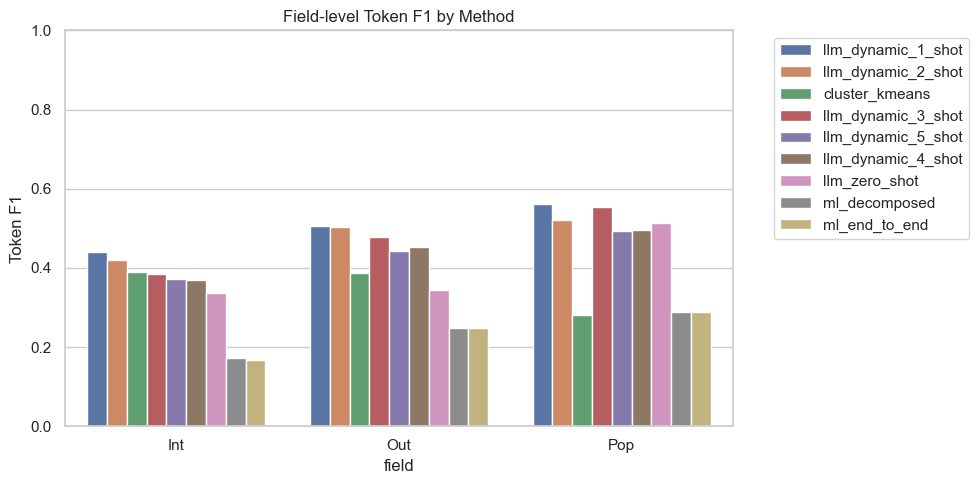

In [29]:
plt.figure(figsize=(10, 5))
if sns:
    sns.barplot(data=field_metrics, x="field", y="f1", hue="method")
else:
    for method, group in field_metrics.groupby("method"):
        plt.plot(group["field"], group["f1"], marker="o", label=method)
plt.ylim(0, 1)
plt.title("Field-level Token F1 by Method")
plt.ylabel("Token F1")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "field_f1_by_method.png", dpi=200)
plt.show()

## B. Coverage vs Precision

Coverage and precision should be read together:

- A method with high coverage but low precision is over-generating.
- A method with low coverage but high precision is conservative.
- Hallucination rate is especially important for LLM outputs.

In [30]:
coverage_precision = (
    field_eval.groupby(["method", "field"])
    .agg(
        gold_coverage=("gold_present", "mean"),
        prediction_coverage=("pred_present", "mean"),
        precision_all=("token_precision", "mean"),
        precision_when_predicted=("token_precision", lambda s: s[field_eval.loc[s.index, "pred_present"]].mean()),
        recall_all=("token_recall", "mean"),
        f1_all=("token_f1", "mean"),
        hallucination_rate_when_predicted=("hallucinated", lambda s: s[field_eval.loc[s.index, "pred_present"]].mean()),
        avg_pred_tokens=("pred_token_count", "mean"),
        avg_gold_tokens=("gold_token_count", "mean"),
    )
    .reset_index()
)

coverage_precision.to_csv(OUTPUT_DIR / "coverage_precision_metrics.csv", index=False)
coverage_precision

,method,field,gold_coverage,prediction_coverage,precision_all,precision_when_predicted,recall_all,f1_all,hallucination_rate_when_predicted,avg_pred_tokens,avg_gold_tokens
0,cluster_kmeans,Int,0.989130,0.608696,0.443188,0.710238,0.426968,0.389338,0.000000,78.929348,123.326087
1,cluster_kmeans,Out,0.978261,0.701087,0.514811,0.718800,0.396948,0.387252,0.000000,73.135870,113.744565
2,cluster_kmeans,Pop,1.000000,0.608696,0.261272,0.429232,0.436826,0.281634,0.000000,78.929348,66.733696
3,llm_dynamic_1_shot,Int,0.989130,1.000000,0.472217,0.472217,0.529283,0.439873,0.032609,18.250000,13.641304
4,llm_dynamic_1_shot,Out,0.978261,1.000000,0.572040,0.572040,0.569984,0.505398,0.043478,22.771739,21.728261
5,llm_dynamic_1_shot,Pop,1.000000,0.961957,0.769140,0.799558,0.518068,0.560437,0.073446,10.576087,16.472826
6,llm_dynamic_2_shot,Int,0.989130,0.989130,0.442080,0.446938,0.516910,0.419668,0.032967,16.940217,13.641304
7,llm_dynamic_2_shot,Out,0.978261,0.994565,0.592489,0.595727,0.554770,0.504260,0.032787,20.836957,21.728261
8,llm_dynamic_2_shot,Pop,1.000000,0.961957,0.773976,0.804586,0.465374,0.520092,0.033898,8.380435,16.472826
9,llm_dynamic_3_shot,Int,0.989130,1.000000,0.504303,0.504303,0.409099,0.383782,0.070652,11.820652,13.641304


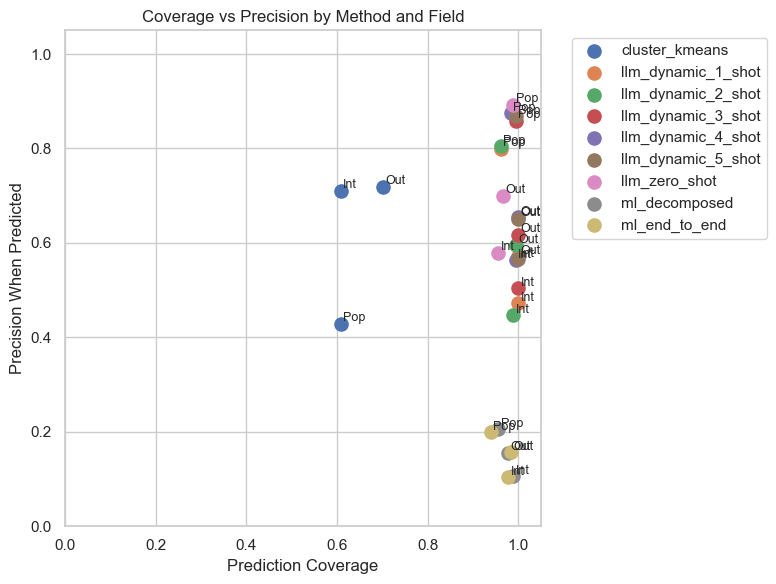

In [31]:
plt.figure(figsize=(8, 6))
for method, group in coverage_precision.groupby("method"):
    plt.scatter(group["prediction_coverage"], group["precision_when_predicted"], s=90, label=method)
    for _, row in group.iterrows():
        plt.text(row["prediction_coverage"] + 0.005, row["precision_when_predicted"] + 0.005, row["field"], fontsize=9)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.xlabel("Prediction Coverage")
plt.ylabel("Precision When Predicted")
plt.title("Coverage vs Precision by Method and Field")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "coverage_vs_precision.png", dpi=200)
plt.show()

## C. Downstream Usability

This section approximates whether extracted tables can support downstream queries:

- Field query answerability: can we answer `What is the Population/Intervention/Outcome?`
- Field query correctness: is the answer relaxed-correct?
- Complete PIO availability: does a row contain all three predicted fields?
- Complete PIO correctness: are all three fields relaxed-correct?

In [32]:
query_usability = (
    field_eval.groupby(["method", "field"])
    .agg(
        query_answerable_rate=("pred_present", "mean"),
        query_relaxed_correct_rate=("relaxed_match", "mean"),
        query_exact_correct_rate=("exact_match", "mean"),
        mean_query_f1=("token_f1", "mean"),
    )
    .reset_index()
)

doc_field = field_eval.pivot_table(
    index=["method", "doc_id"],
    columns="field",
    values=["pred_present", "gold_present", "relaxed_match", "exact_match", "token_f1"],
    aggfunc="first",
)
doc_field.columns = [f"{metric}_{field}" for metric, field in doc_field.columns]
doc_field = doc_field.reset_index()

for metric in ["pred_present", "gold_present", "relaxed_match", "exact_match"]:
    cols = [f"{metric}_{f}" for f in FIELDS]
    doc_field[f"complete_{metric}"] = doc_field[cols].all(axis=1)

doc_field["mean_pio_f1"] = doc_field[[f"token_f1_{f}" for f in FIELDS]].mean(axis=1)

table_usability = (
    doc_field.groupby("method")
    .agg(
        documents=("doc_id", "size"),
        complete_gold_pio_rate=("complete_gold_present", "mean"),
        complete_predicted_pio_rate=("complete_pred_present", "mean"),
        complete_relaxed_correct_pio_rate=("complete_relaxed_match", "mean"),
        complete_exact_correct_pio_rate=("complete_exact_match", "mean"),
        mean_pio_f1=("mean_pio_f1", "mean"),
    )
    .reset_index()
)

query_usability.to_csv(OUTPUT_DIR / "query_usability_metrics.csv", index=False)
table_usability.to_csv(OUTPUT_DIR / "table_usability_metrics.csv", index=False)

query_usability, table_usability

(                method field  query_answerable_rate  \
 0       cluster_kmeans   Int               0.608696   
 1       cluster_kmeans   Out               0.701087   
 2       cluster_kmeans   Pop               0.608696   
 3   llm_dynamic_1_shot   Int               1.000000   
 4   llm_dynamic_1_shot   Out               1.000000   
 5   llm_dynamic_1_shot   Pop               0.961957   
 6   llm_dynamic_2_shot   Int               0.989130   
 7   llm_dynamic_2_shot   Out               0.994565   
 8   llm_dynamic_2_shot   Pop               0.961957   
 9   llm_dynamic_3_shot   Int               1.000000   
 10  llm_dynamic_3_shot   Out               1.000000   
 11  llm_dynamic_3_shot   Pop               0.994565   
 12  llm_dynamic_4_shot   Int               0.994565   
 13  llm_dynamic_4_shot   Out               1.000000   
 14  llm_dynamic_4_shot   Pop               0.983696   
 15  llm_dynamic_5_shot   Int               1.000000   
 16  llm_dynamic_5_shot   Out               1.00

In [33]:
display(query_usability)
display(table_usability)

,method,field,query_answerable_rate,query_relaxed_correct_rate,query_exact_correct_rate,mean_query_f1
0,cluster_kmeans,Int,0.608696,0.429348,0.032609,0.389338
1,cluster_kmeans,Out,0.701087,0.385870,0.043478,0.387252
2,cluster_kmeans,Pop,0.608696,0.298913,0.010870,0.281634
3,llm_dynamic_1_shot,Int,1.000000,0.347826,0.010870,0.439873
4,llm_dynamic_1_shot,Out,1.000000,0.521739,0.005435,0.505398
5,llm_dynamic_1_shot,Pop,0.961957,0.641304,0.021739,0.560437
6,llm_dynamic_2_shot,Int,0.989130,0.347826,0.005435,0.419668
7,llm_dynamic_2_shot,Out,0.994565,0.554348,0.000000,0.504260
8,llm_dynamic_2_shot,Pop,0.961957,0.570652,0.021739,0.520092
9,llm_dynamic_3_shot,Int,1.000000,0.260870,0.005435,0.383782


,method,documents,complete_gold_pio_rate,complete_predicted_pio_rate,complete_relaxed_correct_pio_rate,complete_exact_correct_pio_rate,mean_pio_f1
0,cluster_kmeans,184,0.967391,0.489130,0.081522,0.0,0.352741
1,llm_dynamic_1_shot,184,0.967391,0.961957,0.119565,0.0,0.501903
2,llm_dynamic_2_shot,184,0.967391,0.956522,0.157609,0.0,0.481340
3,llm_dynamic_3_shot,184,0.967391,0.994565,0.108696,0.0,0.471435
4,llm_dynamic_4_shot,184,0.967391,0.978261,0.070652,0.0,0.439532
5,llm_dynamic_5_shot,184,0.967391,0.994565,0.065217,0.0,0.436271
6,llm_zero_shot,184,0.967391,0.913043,0.043478,0.0,0.397505
7,ml_decomposed,184,0.967391,0.929348,0.000000,0.0,0.236180
8,ml_end_to_end,184,0.967391,0.913043,0.000000,0.0,0.234748


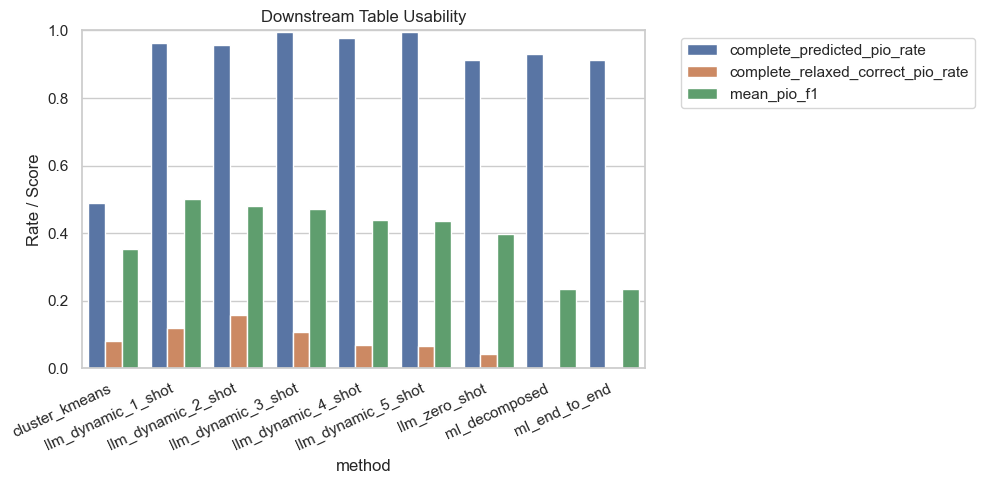

In [34]:
plt.figure(figsize=(10, 5))
plot_df = table_usability.melt(
    id_vars="method",
    value_vars=["complete_predicted_pio_rate", "complete_relaxed_correct_pio_rate", "mean_pio_f1"],
    var_name="metric",
    value_name="score",
)
if sns:
    sns.barplot(data=plot_df, x="method", y="score", hue="metric")
else:
    for metric, group in plot_df.groupby("metric"):
        plt.plot(group["method"], group["score"], marker="o", label=metric)
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.title("Downstream Table Usability")
plt.ylabel("Rate / Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "downstream_usability.png", dpi=200)
plt.show()

## Standard Report Tables

These tables match the most common information-extraction reporting format: per-field precision/recall/F1 plus Macro-F1 and Micro-F1.

In [35]:
field_prf_wide = field_metrics.pivot(index="method", columns="field", values=["precision", "recall", "f1"])
field_prf_wide.columns = [f"{field}_{metric}" for metric, field in field_prf_wide.columns]
field_prf_wide = field_prf_wide.reset_index()

macro_micro = field_eval.groupby("method").agg(
    macro_precision=("token_precision", "mean"),
    macro_recall=("token_recall", "mean"),
    macro_f1=("token_f1", "mean"),
    total_overlap=("overlap_token_count", "sum"),
    total_gold_tokens=("gold_token_count", "sum"),
    total_pred_tokens=("pred_token_count", "sum"),
).reset_index()
macro_micro["micro_precision"] = macro_micro["total_overlap"] / macro_micro["total_pred_tokens"].replace(0, np.nan)
macro_micro["micro_recall"] = macro_micro["total_overlap"] / macro_micro["total_gold_tokens"].replace(0, np.nan)
macro_micro["micro_f1"] = 2 * macro_micro["micro_precision"] * macro_micro["micro_recall"] / (macro_micro["micro_precision"] + macro_micro["micro_recall"])
macro_micro = macro_micro.drop(columns=["total_overlap", "total_gold_tokens", "total_pred_tokens"])

standard_field_table = field_prf_wide.merge(macro_micro, on="method", how="left")
standard_field_table.to_csv(OUTPUT_DIR / "standard_field_prf_macro_micro.csv", index=False)
standard_field_table

,method,Int_precision,Out_precision,Pop_precision,Int_recall,Out_recall,Pop_recall,Int_f1,Out_f1,Pop_f1,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1
0,cluster_kmeans,0.443188,0.514811,0.261272,0.426968,0.396948,0.436826,0.389338,0.387252,0.281634,0.406424,0.420247,0.352741,0.583088,0.443345,0.503704
1,llm_dynamic_1_shot,0.472217,0.572040,0.769140,0.529283,0.569984,0.518068,0.439873,0.505398,0.560437,0.604466,0.539111,0.501903,0.502107,0.499738,0.500919
2,llm_dynamic_2_shot,0.442080,0.592489,0.773976,0.516910,0.554770,0.465374,0.419668,0.504260,0.520092,0.602849,0.512351,0.481340,0.527140,0.469336,0.496562
3,llm_dynamic_3_shot,0.504303,0.617201,0.853915,0.409099,0.492198,0.481245,0.383782,0.476866,0.553658,0.658473,0.460847,0.471435,0.578399,0.407590,0.478199
4,llm_dynamic_4_shot,0.559647,0.654082,0.860806,0.339378,0.426040,0.402626,0.368347,0.454058,0.496192,0.691512,0.389348,0.439532,0.637863,0.340497,0.443989
5,llm_dynamic_5_shot,0.564804,0.651497,0.864238,0.333566,0.400950,0.397300,0.372859,0.442298,0.493655,0.693513,0.377272,0.436271,0.644919,0.332634,0.438896
6,llm_zero_shot,0.564599,0.682810,0.882979,0.295306,0.279124,0.417092,0.335738,0.344319,0.512458,0.710129,0.330507,0.397505,0.643050,0.274033,0.384299
7,ml_decomposed,0.104653,0.157386,0.196210,0.725048,0.757805,0.751652,0.171839,0.247302,0.289399,0.152750,0.744835,0.236180,0.140669,0.774085,0.238075
8,ml_end_to_end,0.100950,0.159657,0.187376,0.731970,0.781885,0.800342,0.167971,0.248789,0.287485,0.149328,0.771399,0.234748,0.139375,0.807946,0.237738


## Coverage and Row Completeness

This section separates whether the table is filled from whether the filled values are correct.

In [36]:
doc_presence = field_eval.pivot_table(index=["method", "doc_id"], columns="field", values="pred_present", aggfunc="first").reset_index()
doc_presence["any_field_coverage"] = doc_presence[FIELDS].any(axis=1)
doc_presence["valid_row_coverage"] = doc_presence[FIELDS].sum(axis=1) >= 2
doc_presence["complete_row_coverage"] = doc_presence[FIELDS].all(axis=1)

field_coverage_wide = coverage_precision.pivot(index="method", columns="field", values="prediction_coverage")
field_coverage_wide.columns = [f"{field}_coverage" for field in field_coverage_wide.columns]
field_coverage_wide = field_coverage_wide.reset_index()

row_coverage = doc_presence.groupby("method").agg(
    any_field_coverage=("any_field_coverage", "mean"),
    valid_row_coverage=("valid_row_coverage", "mean"),
    complete_row_coverage=("complete_row_coverage", "mean"),
).reset_index()

coverage_table = field_coverage_wide.merge(row_coverage, on="method", how="left")
coverage_table["average_field_coverage"] = coverage_table[[f"{f}_coverage" for f in FIELDS]].mean(axis=1)
coverage_table.to_csv(OUTPUT_DIR / "coverage_row_completeness.csv", index=False)
coverage_table

,method,Int_coverage,Out_coverage,Pop_coverage,any_field_coverage,valid_row_coverage,complete_row_coverage,average_field_coverage
0,cluster_kmeans,0.608696,0.701087,0.608696,0.820652,0.608696,0.489130,0.639493
1,llm_dynamic_1_shot,1.000000,1.000000,0.961957,1.000000,1.000000,0.961957,0.987319
2,llm_dynamic_2_shot,0.989130,0.994565,0.961957,0.994565,0.994565,0.956522,0.981884
3,llm_dynamic_3_shot,1.000000,1.000000,0.994565,1.000000,1.000000,0.994565,0.998188
4,llm_dynamic_4_shot,0.994565,1.000000,0.983696,1.000000,1.000000,0.978261,0.992754
5,llm_dynamic_5_shot,1.000000,1.000000,0.994565,1.000000,1.000000,0.994565,0.998188
6,llm_zero_shot,0.956522,0.967391,0.989130,1.000000,1.000000,0.913043,0.971014
7,ml_decomposed,0.989130,0.978261,0.956522,1.000000,0.994565,0.929348,0.974638
8,ml_end_to_end,0.978261,0.983696,0.940217,1.000000,0.989130,0.913043,0.967391


## Precision Among Non-empty Predictions, Missing Rate, and Hallucination

In [37]:
def safe_mean(series):
    return series.mean() if len(series) else np.nan

non_empty_quality = (
    field_eval.groupby(["method", "field"])
    .apply(lambda g: pd.Series({
        "non_empty_predictions": int(g["pred_present"].sum()),
        "strict_precision_non_empty": safe_mean(g.loc[g["pred_present"], "exact_match"]),
        "relaxed_precision_non_empty": safe_mean(g.loc[g["pred_present"], "relaxed_match"]),
        "mean_token_precision_non_empty": safe_mean(g.loc[g["pred_present"], "token_precision"]),
        "missing_rate": ((g["gold_present"]) & (~g["pred_present"])).sum() / max(1, g["gold_present"].sum()),
        "source_hallucination_rate": safe_mean(g.loc[g["pred_present"], "hallucinated"]),
        "avg_hallucination_fraction": safe_mean(g.loc[g["pred_present"], "hallucination_fraction"]),
    }))
    .reset_index()
)
non_empty_quality.to_csv(OUTPUT_DIR / "non_empty_precision_missing_hallucination.csv", index=False)
non_empty_quality

C:\Users\eik\AppData\Local\Temp\ipykernel_21912\4243887833.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,method,field,non_empty_predictions,strict_precision_non_empty,relaxed_precision_non_empty,mean_token_precision_non_empty,missing_rate,source_hallucination_rate,avg_hallucination_fraction
0,cluster_kmeans,Int,112.0,0.035714,0.687500,0.710238,0.384615,0.000000,0.000000
1,cluster_kmeans,Out,129.0,0.046512,0.534884,0.718800,0.294444,0.000000,0.000000
2,cluster_kmeans,Pop,112.0,0.017857,0.491071,0.429232,0.391304,0.000000,0.000000
3,llm_dynamic_1_shot,Int,184.0,0.010870,0.347826,0.472217,0.000000,0.032609,0.004768
4,llm_dynamic_1_shot,Out,184.0,0.005435,0.521739,0.572040,0.000000,0.043478,0.003956
5,llm_dynamic_1_shot,Pop,177.0,0.022599,0.666667,0.799558,0.038043,0.073446,0.015917
6,llm_dynamic_2_shot,Int,182.0,0.005495,0.351648,0.446938,0.010989,0.032967,0.004859
7,llm_dynamic_2_shot,Out,183.0,0.000000,0.557377,0.595727,0.005556,0.032787,0.002619
8,llm_dynamic_2_shot,Pop,177.0,0.022599,0.593220,0.804586,0.038043,0.033898,0.004837
9,llm_dynamic_3_shot,Int,184.0,0.005435,0.260870,0.504303,0.000000,0.070652,0.008733


## Faithfulness / Groundedness

For extractive biomedical IE, predictions should be grounded in the abstract. Verbatim match is stricter than token-level extractiveness.

In [38]:
faithfulness = (
    field_eval.groupby(["method", "field"])
    .agg(
        extractiveness_rate=("extractiveness_rate", "mean"),
        verbatim_match_rate=("verbatim_match_rate", "mean"),
        source_hallucination_rate=("hallucinated", lambda s: s[field_eval.loc[s.index, "pred_present"]].mean()),
    )
    .reset_index()
)
faithfulness.to_csv(OUTPUT_DIR / "faithfulness_groundedness.csv", index=False)
faithfulness

,method,field,extractiveness_rate,verbatim_match_rate,source_hallucination_rate
0,cluster_kmeans,Int,1.000000,1.000000,0.000000
1,cluster_kmeans,Out,1.000000,1.000000,0.000000
2,cluster_kmeans,Pop,1.000000,1.000000,0.000000
3,llm_dynamic_1_shot,Int,0.991473,0.823999,0.032609
4,llm_dynamic_1_shot,Out,0.986957,0.859075,0.043478
5,llm_dynamic_1_shot,Pop,0.962241,0.816021,0.073446
6,llm_dynamic_2_shot,Int,0.980617,0.776237,0.032967
7,llm_dynamic_2_shot,Out,0.983888,0.818823,0.032787
8,llm_dynamic_2_shot,Pop,0.981921,0.811864,0.033898
9,llm_dynamic_3_shot,Int,0.929348,0.376906,0.070652


## Boundary Quality

Sentence-level systems often over-extract; LLM systems may under-extract or paraphrase. Length ratios help quantify this.

In [39]:
boundary_eval = field_eval.copy()
boundary_eval["length_ratio"] = boundary_eval["pred_token_count"] / boundary_eval["gold_token_count"].replace(0, np.nan)
boundary_eval["over_extracted"] = boundary_eval["gold_present"] & boundary_eval["pred_present"] & (boundary_eval["length_ratio"] > 3.0) & (boundary_eval["token_recall"] >= 0.5)
boundary_eval["under_extracted"] = boundary_eval["gold_present"] & boundary_eval["pred_present"] & (boundary_eval["token_precision"] >= 0.5) & (boundary_eval["token_recall"] < 0.5)

boundary_quality = boundary_eval.groupby(["method", "field"]).agg(
    avg_gold_tokens=("gold_token_count", "mean"),
    avg_pred_tokens=("pred_token_count", "mean"),
    median_length_ratio=("length_ratio", "median"),
    over_extraction_rate=("over_extracted", "mean"),
    under_extraction_rate=("under_extracted", "mean"),
).reset_index()
boundary_quality.to_csv(OUTPUT_DIR / "boundary_quality.csv", index=False)
boundary_quality

,method,field,avg_gold_tokens,avg_pred_tokens,median_length_ratio,over_extraction_rate,under_extraction_rate
0,cluster_kmeans,Int,123.326087,78.929348,0.374245,0.016304,0.125000
1,cluster_kmeans,Out,113.744565,73.135870,0.400182,0.032609,0.250000
2,cluster_kmeans,Pop,66.733696,78.929348,0.538222,0.135870,0.048913
3,llm_dynamic_1_shot,Int,13.641304,18.250000,1.233032,0.076087,0.190217
4,llm_dynamic_1_shot,Out,21.728261,22.771739,1.000000,0.092391,0.250000
5,llm_dynamic_1_shot,Pop,16.472826,10.576087,0.618037,0.038043,0.391304
6,llm_dynamic_2_shot,Int,13.641304,16.940217,1.250000,0.076087,0.152174
7,llm_dynamic_2_shot,Out,21.728261,20.836957,1.000000,0.076087,0.255435
8,llm_dynamic_2_shot,Pop,16.472826,8.380435,0.535897,0.021739,0.429348
9,llm_dynamic_3_shot,Int,13.641304,11.820652,0.868116,0.054348,0.304348


## Field Confusion / Cross-field Contamination

A prediction is counted as contaminated when it overlaps another gold field more than its intended field.

In [40]:
confusion_records = []
for _, row in predictions.iterrows():
    for pred_field in FIELDS:
        pred = normalize_prediction_value(row[f"{pred_field}_pred"])
        if not is_present(pred):
            confusion_records.append({"method": row["method"], "doc_id": row["doc_id"], "pred_field": pred_field, "best_gold_field": "None", "best_f1": 0.0, "own_f1": 0.0, "contaminated": False})
            continue
        scores = {gold_field: token_scores(row[f"{gold_field}_gold"], pred)[2] for gold_field in FIELDS}
        best_gold_field = max(scores, key=scores.get)
        own_f1 = scores[pred_field]
        best_f1 = scores[best_gold_field]
        confusion_records.append({
            "method": row["method"],
            "doc_id": row["doc_id"],
            "pred_field": pred_field,
            "best_gold_field": best_gold_field,
            "best_f1": best_f1,
            "own_f1": own_f1,
            "contaminated": best_gold_field != pred_field and best_f1 >= RELAXED_F1_THRESHOLD and best_f1 > own_f1,
        })

field_confusion_rows = pd.DataFrame(confusion_records)
field_confusion_matrix = pd.crosstab(
    [field_confusion_rows["method"], field_confusion_rows["pred_field"]],
    field_confusion_rows["best_gold_field"],
    normalize="index",
).reset_index()
contamination_rate = field_confusion_rows.groupby(["method", "pred_field"]).agg(cross_field_contamination_rate=("contaminated", "mean")).reset_index()

field_confusion_rows.to_csv(OUTPUT_DIR / "field_confusion_rows.csv", index=False)
field_confusion_matrix.to_csv(OUTPUT_DIR / "field_confusion_matrix.csv", index=False)
contamination_rate.to_csv(OUTPUT_DIR / "cross_field_contamination.csv", index=False)
display(field_confusion_matrix)
display(contamination_rate)

best_gold_field,method,pred_field,Int,None,Out,Pop
0,cluster_kmeans,Int,0.342391,0.391304,0.125000,0.141304
1,cluster_kmeans,Out,0.190217,0.298913,0.445652,0.065217
2,cluster_kmeans,Pop,0.342391,0.391304,0.125000,0.141304
3,llm_dynamic_1_shot,Int,0.913043,0.000000,0.038043,0.048913
4,llm_dynamic_1_shot,Out,0.005435,0.000000,0.923913,0.070652
5,llm_dynamic_1_shot,Pop,0.016304,0.038043,0.016304,0.929348
6,llm_dynamic_2_shot,Int,0.902174,0.010870,0.038043,0.048913
7,llm_dynamic_2_shot,Out,0.005435,0.005435,0.934783,0.054348
8,llm_dynamic_2_shot,Pop,0.005435,0.038043,0.021739,0.934783
9,llm_dynamic_3_shot,Int,0.923913,0.000000,0.032609,0.043478


,method,pred_field,cross_field_contamination_rate
0,cluster_kmeans,Int,0.195652
1,cluster_kmeans,Out,0.173913
2,cluster_kmeans,Pop,0.375000
3,llm_dynamic_1_shot,Int,0.016304
4,llm_dynamic_1_shot,Out,0.000000
5,llm_dynamic_1_shot,Pop,0.005435
6,llm_dynamic_2_shot,Int,0.016304
7,llm_dynamic_2_shot,Out,0.000000
8,llm_dynamic_2_shot,Pop,0.010870
9,llm_dynamic_3_shot,Int,0.005435


## Downstream Query Evaluation

Gold tables define relevance; method tables define retrieved documents. This gives query precision, recall, F1, and Precision@K.

In [41]:
QUERY_SPECS = [
    {"query": "elderly patients", "field": "Pop", "terms": ["elderly", "older", "aged", "over 65"]},
    {"query": "children", "field": "Pop", "terms": ["children", "paediatric", "pediatric", "preschool"]},
    {"query": "placebo intervention", "field": "Int", "terms": ["placebo"]},
    {"query": "mortality or survival outcome", "field": "Out", "terms": ["mortality", "death", "survival"]},
    {"query": "pain outcome", "field": "Out", "terms": ["pain"]},
    {"query": "quality of life outcome", "field": "Out", "terms": ["quality of life", "qol"]},
]

def contains_any(text, terms):
    text = normalize_prediction_value(text).lower()
    return any(term.lower() in text for term in terms)

query_rows = []
for method, group in predictions.groupby("method"):
    for spec in QUERY_SPECS:
        field = spec["field"]
        gold_relevant = group[f"{field}_gold"].apply(lambda x: contains_any(x, spec["terms"]))
        pred_relevant = group[f"{field}_pred"].apply(lambda x: contains_any(x, spec["terms"]))
        tp = int((gold_relevant & pred_relevant).sum())
        fp = int((~gold_relevant & pred_relevant).sum())
        fn = int((gold_relevant & ~pred_relevant).sum())
        precision = tp / (tp + fp) if tp + fp else np.nan
        recall = tp / (tp + fn) if tp + fn else np.nan
        f1 = 2 * precision * recall / (precision + recall) if precision == precision and recall == recall and precision + recall else np.nan
        ranked = group.assign(_retrieved=pred_relevant, _relevant=gold_relevant).sort_values("_retrieved", ascending=False)
        k = min(20, len(ranked))
        precision_at_k = ranked.head(k)["_relevant"].mean() if k else np.nan
        query_rows.append({
            "method": method,
            "query": spec["query"],
            "field": field,
            "gold_relevant_docs": int(gold_relevant.sum()),
            "retrieved_docs": int(pred_relevant.sum()),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "query_precision": precision,
            "query_recall": recall,
            "query_f1": f1,
            "precision_at_20": precision_at_k,
        })

downstream_query_metrics = pd.DataFrame(query_rows)
downstream_query_metrics.to_csv(OUTPUT_DIR / "downstream_query_metrics.csv", index=False)
downstream_query_metrics

,method,query,field,gold_relevant_docs,retrieved_docs,tp,fp,fn,query_precision,query_recall,query_f1,precision_at_20
0,cluster_kmeans,elderly patients,Pop,18,10,7,3,11,0.700000,0.388889,0.500000,0.40
1,cluster_kmeans,children,Pop,35,6,6,0,29,1.000000,0.171429,0.292683,0.50
2,cluster_kmeans,placebo intervention,Int,45,31,31,0,14,1.000000,0.688889,0.815789,1.00
3,cluster_kmeans,mortality or survival outcome,Out,12,8,7,1,5,0.875000,0.583333,0.700000,0.35
4,cluster_kmeans,pain outcome,Out,14,2,2,0,12,1.000000,0.142857,0.250000,0.20
5,cluster_kmeans,quality of life outcome,Out,10,3,3,0,7,1.000000,0.300000,0.461538,0.30
6,llm_dynamic_1_shot,elderly patients,Pop,17,13,12,1,5,0.923077,0.705882,0.800000,0.60
7,llm_dynamic_1_shot,children,Pop,33,32,32,0,1,1.000000,0.969697,0.984615,1.00
8,llm_dynamic_1_shot,placebo intervention,Int,40,37,34,3,6,0.918919,0.850000,0.883117,0.95
9,llm_dynamic_1_shot,mortality or survival outcome,Out,12,12,11,1,1,0.916667,0.916667,0.916667,0.55


## Error Type Breakdown

Each field prediction is assigned one primary error type for interpretability.

In [42]:
def classify_error(row):
    if row["gold_present"] and not row["pred_present"]:
        return "Missing field"
    if row["pred_present"] and not row["gold_present"]:
        return "Spurious field"
    if not row["gold_present"] and not row["pred_present"]:
        return "Correct null"
    if row["hallucinated"]:
        return "Source hallucination"
    if row["exact_match"]:
        return "Exact hit"
    if row["relaxed_match"]:
        ratio = row["pred_token_count"] / row["gold_token_count"] if row["gold_token_count"] else np.nan
        if ratio == ratio and ratio > 3:
            return "Overlong partial hit"
        if row["token_recall"] < 0.5:
            return "Too short partial hit"
        return "Partial hit"
    return "Wrong field / low overlap"

error_rows = field_eval.copy()
error_rows["error_type"] = error_rows.apply(classify_error, axis=1)
error_breakdown = pd.crosstab(
    [error_rows["method"], error_rows["field"]],
    error_rows["error_type"],
    normalize="index",
).reset_index()
error_counts = pd.crosstab([error_rows["method"], error_rows["field"]], error_rows["error_type"]).reset_index()

error_rows.to_csv(OUTPUT_DIR / "error_type_rows.csv", index=False)
error_breakdown.to_csv(OUTPUT_DIR / "error_type_breakdown_rates.csv", index=False)
error_counts.to_csv(OUTPUT_DIR / "error_type_breakdown_counts.csv", index=False)
error_breakdown

error_type,method,field,Correct null,Exact hit,Missing field,Partial hit,Source hallucination,Spurious field,Too short partial hit,Wrong field / low overlap
0,cluster_kmeans,Int,0.010870,0.021739,0.380435,0.380435,0.000000,0.000000,0.016304,0.190217
1,cluster_kmeans,Out,0.010870,0.032609,0.288043,0.271739,0.000000,0.010870,0.070652,0.315217
2,cluster_kmeans,Pop,0.000000,0.010870,0.391304,0.255435,0.000000,0.000000,0.032609,0.309783
3,llm_dynamic_1_shot,Int,0.000000,0.010870,0.000000,0.277174,0.032609,0.010870,0.054348,0.614130
4,llm_dynamic_1_shot,Out,0.000000,0.005435,0.000000,0.385870,0.043478,0.021739,0.114130,0.429348
5,llm_dynamic_1_shot,Pop,0.000000,0.021739,0.038043,0.407609,0.070652,0.000000,0.173913,0.288043
6,llm_dynamic_2_shot,Int,0.000000,0.005435,0.010870,0.282609,0.032609,0.010870,0.048913,0.608696
7,llm_dynamic_2_shot,Out,0.000000,0.000000,0.005435,0.423913,0.032609,0.021739,0.114130,0.402174
8,llm_dynamic_2_shot,Pop,0.000000,0.021739,0.038043,0.358696,0.032609,0.000000,0.163043,0.385870
9,llm_dynamic_3_shot,Int,0.000000,0.005435,0.000000,0.201087,0.070652,0.010870,0.043478,0.668478


## Robustness by Abstract Length and Field Density

In [43]:
robustness_rows = field_eval.copy()
robustness_rows["abstract_length_group"] = pd.qcut(robustness_rows["abstract_token_count"], q=3, labels=["short", "medium", "long"], duplicates="drop")
robustness_rows["sentence_count_group"] = pd.cut(robustness_rows["sentence_count"], bins=[0, 5, 10, 10**9], labels=["1-5", "6-10", ">10"])
robustness_rows["field_density"] = robustness_rows["gold_token_count"] / robustness_rows["abstract_token_count"].replace(0, np.nan)
robustness_rows["field_density_group"] = pd.qcut(robustness_rows["field_density"], q=3, labels=["low", "medium", "high"], duplicates="drop")

robustness_by_length = robustness_rows.groupby(["method", "field", "abstract_length_group"], observed=False).agg(f1=("token_f1", "mean"), recall=("token_recall", "mean"), precision=("token_precision", "mean"), n=("doc_id", "size")).reset_index()
robustness_by_sentences = robustness_rows.groupby(["method", "field", "sentence_count_group"], observed=False).agg(f1=("token_f1", "mean"), n=("doc_id", "size")).reset_index()
robustness_by_density = robustness_rows.groupby(["method", "field", "field_density_group"], observed=False).agg(f1=("token_f1", "mean"), recall=("token_recall", "mean"), n=("doc_id", "size")).reset_index()

robustness_by_length.to_csv(OUTPUT_DIR / "robustness_by_abstract_length.csv", index=False)
robustness_by_sentences.to_csv(OUTPUT_DIR / "robustness_by_sentence_count.csv", index=False)
robustness_by_density.to_csv(OUTPUT_DIR / "robustness_by_field_density.csv", index=False)
display(robustness_by_length.head(12))
display(robustness_by_density.head(12))

,method,field,abstract_length_group,f1,recall,precision,n
0,cluster_kmeans,Int,short,0.388096,0.406531,0.431585,62
1,cluster_kmeans,Int,medium,0.384394,0.414368,0.454047,62
2,cluster_kmeans,Int,long,0.395730,0.461108,0.443959,60
3,cluster_kmeans,Out,short,0.358054,0.358973,0.447633,62
4,cluster_kmeans,Out,medium,0.403968,0.421574,0.542130,62
5,cluster_kmeans,Out,long,0.400148,0.410741,0.555999,60
6,cluster_kmeans,Pop,short,0.307942,0.432975,0.295614,62
7,cluster_kmeans,Pop,medium,0.248785,0.391282,0.239207,62
8,cluster_kmeans,Pop,long,0.288395,0.487869,0.248585,60
9,llm_dynamic_1_shot,Int,short,0.471544,0.573570,0.489529,62


,method,field,field_density_group,f1,recall,n
0,cluster_kmeans,Int,low,1.000000,1.000000,2
1,cluster_kmeans,Int,medium,0.237647,0.269565,5
2,cluster_kmeans,Int,high,0.386723,0.424940,177
3,cluster_kmeans,Out,low,0.428571,0.488889,5
4,cluster_kmeans,Out,medium,0.143791,0.174603,3
5,cluster_kmeans,Out,high,0.390228,0.398125,176
6,cluster_kmeans,Pop,low,0.003766,0.047619,3
7,cluster_kmeans,Pop,medium,0.080917,0.306122,7
8,cluster_kmeans,Pop,high,0.294500,0.448795,174
9,llm_dynamic_1_shot,Int,low,0.392980,0.547666,89


## Ranking and Interpretation Helper

The final ranking below is only a convenience score. In the report, discuss the separate metric tables because methods may trade precision against coverage.

In [44]:
method_summary = (
    field_metrics.groupby("method")
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1", "mean"),
        macro_exact=("exact_accuracy", "mean"),
        macro_relaxed=("relaxed_accuracy", "mean"),
    )
    .reset_index()
    .merge(
        coverage_precision.groupby("method").agg(
            avg_coverage=("prediction_coverage", "mean"),
            avg_hallucination_rate=("hallucination_rate_when_predicted", "mean"),
        ).reset_index(),
        on="method",
        how="left",
    )
    .merge(table_usability[["method", "complete_predicted_pio_rate", "complete_relaxed_correct_pio_rate", "mean_pio_f1"]], on="method", how="left")
)

method_summary["balanced_score"] = (
    0.45 * method_summary["macro_f1"]
    + 0.20 * method_summary["macro_relaxed"]
    + 0.20 * method_summary["mean_pio_f1"]
    + 0.15 * method_summary["complete_relaxed_correct_pio_rate"]
    - 0.10 * method_summary["avg_hallucination_rate"].fillna(0)
)

method_summary = method_summary.sort_values("balanced_score", ascending=False)
method_summary.to_csv(OUTPUT_DIR / "method_summary_ranking.csv", index=False)
method_summary

,method,macro_precision,macro_recall,macro_f1,macro_exact,macro_relaxed,avg_coverage,avg_hallucination_rate,complete_predicted_pio_rate,complete_relaxed_correct_pio_rate,mean_pio_f1,balanced_score
1,llm_dynamic_1_shot,0.604466,0.539111,0.501903,0.012681,0.503623,0.987319,0.049844,0.961957,0.119565,0.501903,0.439912
2,llm_dynamic_2_shot,0.602849,0.512351,0.481340,0.009058,0.490942,0.981884,0.033217,0.956522,0.157609,0.481340,0.431379
3,llm_dynamic_3_shot,0.658473,0.460847,0.471435,0.019928,0.449275,0.998188,0.094371,0.994565,0.108696,0.471435,0.403155
4,llm_dynamic_4_shot,0.691512,0.389348,0.439532,0.021739,0.385870,0.992754,0.100267,0.978261,0.070652,0.439532,0.363441
5,llm_dynamic_5_shot,0.693513,0.377272,0.436271,0.021739,0.362319,0.998188,0.096183,0.994565,0.065217,0.436271,0.356204
6,llm_zero_shot,0.710129,0.330507,0.397505,0.030797,0.329710,0.971014,0.005598,0.913043,0.043478,0.397505,0.330282
0,cluster_kmeans,0.406424,0.420247,0.352741,0.028986,0.371377,0.639493,0.000000,0.489130,0.081522,0.352741,0.315786
7,ml_decomposed,0.152750,0.744835,0.236180,0.001812,0.045290,0.974638,0.000000,0.929348,0.000000,0.236180,0.162575
8,ml_end_to_end,0.149328,0.771399,0.234748,0.001812,0.039855,0.967391,0.000000,0.913043,0.000000,0.234748,0.160557


## Final Evaluation Framework

The final framework used by this notebook is:

| Evaluation dimension | Metrics produced | Why it matters |
|---|---|---|
| Field-level quality | Pop/Int/Out precision, recall, F1; Macro-F1; Micro-F1 | Measures extraction correctness per schema field |
| Boundary quality | Exact match, relaxed match, token overlap, length ratio, over/under-extraction | Shows whether spans are too long, too short, or boundary-accurate |
| Coverage | Field coverage, any-field coverage, valid-row coverage, complete-row coverage | Measures whether the table is sufficiently filled |
| Coverage vs precision | Precision among non-empty predictions, missing rate, hallucination rate | Separates useful coverage from noisy over-generation |
| Faithfulness | Extractiveness rate, verbatim match rate, source hallucination | Critical for biomedical evidence extraction |
| Field confusion | Cross-field contamination and approximate confusion matrix | Shows whether P/I/O fields are mixed up |
| Downstream usability | Query precision/recall/F1, Precision@20, complete PIO usability | Tests whether the table can answer evidence-search questions |
| Robustness | F1 by abstract length, sentence count, field density | Shows when each method fails |
| Error analysis | Missing, spurious, overlong, too short, hallucination, wrong-field errors | Explains model behavior beyond aggregate scores |

## Recommended Report Structure

Use the generated CSVs and figures in `evaluation_outputs/` to write the evaluation section:

1. **Setup**: list methods and mention that all outputs were converted to the same prediction-table schema.
2. **Field-level performance**: report macro and per-field token precision/recall/F1, plus exact/relaxed accuracy.
3. **Coverage vs precision**: identify methods that over-generate versus under-generate.
4. **Downstream usability**: report whether Pop/Int/Out questions can be answered and whether complete PIO rows are usable.
5. **Error analysis**: inspect methods with high coverage but low precision, especially sentence-level ML or clustering outputs.
6. **Conclusion**: choose the best method based on the task goal, not only the highest single score.